<a href="https://colab.research.google.com/github/Aya-ahmedd/DataAnalysis-ITI-/blob/main/Stat2(ITI).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
try:
    df = pd.read_excel('/content/sample_data/tips.xlsx')
    print("Successfully loaded tips.xlsx from local path.")
except Exception as e:
    print("Local Excel file not found. Loading from seaborn library instead...")
    df = sns.load_dataset('tips')

print("\n--- First 5 rows of the dataset ---")
display(df.head())

Successfully loaded tips.xlsx from local path.

--- First 5 rows of the dataset ---


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [10]:
print("PART 1 & 2: DATA TYPES & EXPLORATION")
print("\n[Tasks 3-7] Data Types:")
print(df.dtypes)

print("\n[Tasks 8-13] Frequency Counts:")
print("Smokers vs Non-Smokers:\n", df['smoker'].value_counts())
print("\nGender Counts:\n", df['sex'].value_counts())
print("\nVisits per Day:\n", df['day'].value_counts())
print("\nLunch vs Dinner Visits:\n", df['time'].value_counts())
print("\nParty Size Frequency:\n", df['size'].value_counts())

PART 1 & 2: DATA TYPES & EXPLORATION

[Tasks 3-7] Data Types:
total_bill    float64
tip           float64
sex            object
smoker         object
day            object
time           object
size            int64
dtype: object

[Tasks 8-13] Frequency Counts:
Smokers vs Non-Smokers:
 smoker
No     151
Yes     92
Name: count, dtype: int64

Gender Counts:
 sex
Male      157
Female     86
Name: count, dtype: int64

Visits per Day:
 day
Sat     87
Sun     76
Thur    61
Fri     19
Name: count, dtype: int64

Lunch vs Dinner Visits:
 time
Dinner    176
Lunch      67
Name: count, dtype: int64

Party Size Frequency:
 size
2    155
3     38
4     37
5      5
1      4
6      4
Name: count, dtype: int64


In [9]:
print("PART 3: CENTRAL TENDENCY")
print(f"Mean Total Bill: ${df['total_bill'].mean():.2f}")
print(f"Median Total Bill: ${df['total_bill'].median():.2f}")
print(f"Mode Party Size: {df['size'].mode()[0]}")
print(f"Mean Tip: ${df['tip'].mean():.2f}")
print(f"Median Tip: ${df['tip'].median():.2f}")

PART 3: CENTRAL TENDENCY
Mean Total Bill: $19.81
Median Total Bill: $17.81
Mode Party Size: 2
Mean Tip: $3.00
Median Tip: $2.92


In [8]:
print("PART 4 & 5: SPREAD, IQR & OUTLIERS")
print(f"Total Bill - Min: ${df['total_bill'].min():.2f}, Max: ${df['total_bill'].max():.2f}, Range: ${df['total_bill'].max() - df['total_bill'].min():.2f}")
print(f"Tip - Min: ${df['tip'].min():.2f}, Max: ${df['tip'].max():.2f}, Range: ${df['tip'].max() - df['tip'].min():.2f}")

print(f"Total Bill Variance: {df['total_bill'].var():.4f}, Standard Deviation: ${df['total_bill'].std():.2f}")
print(f"Tip Variance: {df['tip'].var():.4f}, Standard Deviation: ${df['tip'].std():.2f}")


PART 4 & 5: SPREAD, IQR & OUTLIERS
Total Bill - Min: $3.07, Max: $50.81, Range: $47.74
Tip - Min: $1.00, Max: $10.00, Range: $9.00
Total Bill Variance: 79.3894, Standard Deviation: $8.91
Tip Variance: 1.9182, Standard Deviation: $1.39


In [11]:
print("PART 6:DISTRIBUTION & SKEWNESS")
print(f"Total Bill Skewness: {df['total_bill'].skew():.4f}")
print(f"Tip Skewness: {df['tip'].skew():.4f}")

PART 6:DISTRIBUTION & SKEWNESS
Total Bill Skewness: 1.1274
Tip Skewness: 1.4598


In [12]:
print("PART 7: COMPARING GROUPS")
print("Average Total Bill by Day:\n", df.groupby('day')['total_bill'].mean().round(2))
print("\nAverage Tip by Day:\n", df.groupby('day')['tip'].mean().round(2))
print("\nAverage Tip by Smoker Status:\n", df.groupby('smoker')['tip'].mean().round(2))
print("\nAverage Tip by Gender:\n", df.groupby('sex')['tip'].mean().round(2))
print("\nAverage Tip by Time (Lunch/Dinner):\n", df.groupby('time')['tip'].mean().round(2))

PART 7: COMPARING GROUPS
Average Total Bill by Day:
 day
Fri     17.15
Sat     20.44
Sun     21.41
Thur    17.76
Name: total_bill, dtype: float64

Average Tip by Day:
 day
Fri     2.73
Sat     2.99
Sun     3.26
Thur    2.78
Name: tip, dtype: float64

Average Tip by Smoker Status:
 smoker
No     2.99
Yes    3.02
Name: tip, dtype: float64

Average Tip by Gender:
 sex
Female    2.84
Male      3.09
Name: tip, dtype: float64

Average Tip by Time (Lunch/Dinner):
 time
Dinner    3.10
Lunch     2.74
Name: tip, dtype: float64


In [13]:
print("PARTS 8-10: COVARIANCE, CORRELATION & REGRESSION")
cov_val = np.cov(df['total_bill'], df['tip'])[0, 1]
corr_val = df['total_bill'].corr(df['tip'])
print(f"Covariance (Total Bill & Tip): {cov_val:.4f}")
print(f"Correlation Coefficient (r): {corr_val:.4f}")

# Linear Regression
slope, intercept, r_value, p_value, std_err = stats.linregress(df['total_bill'], df['tip'])
print(f"\nLinear Regression Equation: tip = {slope:.4f} * total_bill + {intercept:.4f}")
print(f"R-squared: {r_value**2:.4f}")

# Predictions for Tasks 88 & 89
bill_30_pred = slope * 30 + intercept
bill_50_pred = slope * 50 + intercept
print(f"Estimated tip for a $30 bill: ${bill_30_pred:.2f}")
print(f"Estimated tip for a $50 bill: ${bill_50_pred:.2f}")

PARTS 8-10: COVARIANCE, CORRELATION & REGRESSION
Covariance (Total Bill & Tip): 8.3298
Correlation Coefficient (r): 0.6750

Linear Regression Equation: tip = 0.1049 * total_bill + 0.9235
R-squared: 0.4556
Estimated tip for a $30 bill: $4.07
Estimated tip for a $50 bill: $6.17


In [14]:
print("PART 17: CONFIDENCE INTERVAL FOR POPULATION MEAN TIP")
tip_mean = df['tip'].mean()
tip_sem = stats.sem(df['tip'])
confidence_interval = stats.t.interval(0.95, len(df)-1, loc=tip_mean, scale=tip_sem)
print(f"95% Confidence Interval for Mean Tip: (${confidence_interval[0]:.2f}, ${confidence_interval[1]:.2f})")

PART 17: CONFIDENCE INTERVAL FOR POPULATION MEAN TIP
95% Confidence Interval for Mean Tip: ($2.83, $3.18)


/tmp/ipykernel_5340/2842901435.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='day', order=['Thur', 'Fri', 'Sat', 'Sun'], palette='viridis')


Text(0, 0.5, 'Count')

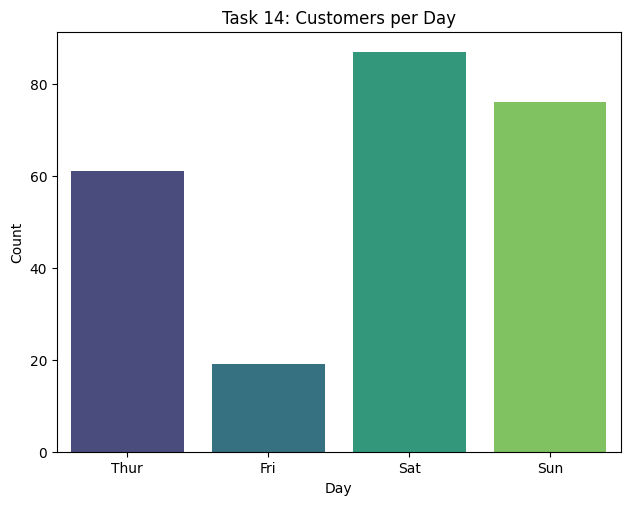

In [15]:
plt.figure(figsize=(16, 12))
# 1. Customers per Day
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='day', order=['Thur', 'Fri', 'Sat', 'Sun'], palette='viridis')
plt.title('Task 14: Customers per Day')
plt.xlabel('Day')
plt.ylabel('Count')

/tmp/ipykernel_5340/2573346678.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='time', palette='magma')


Text(0, 0.5, 'Count')

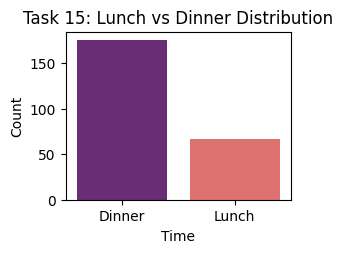

In [16]:
# 2.Lunch vs Dinner Distribution
plt.subplot(2, 2, 2)
sns.countplot(data=df, x='time', palette='magma')
plt.title('Task 15: Lunch vs Dinner Distribution')
plt.xlabel('Time')
plt.ylabel('Count')

Text(0, 0.5, 'USD ($)')

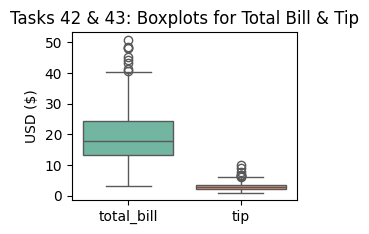

In [17]:
# 3. Boxplot for Total Bill & Tip
plt.subplot(2, 2, 3)
sns.boxplot(data=df[['total_bill', 'tip']], palette='Set2')
plt.title('Tasks 42 & 43: Boxplots for Total Bill & Tip')
plt.ylabel('USD ($)')

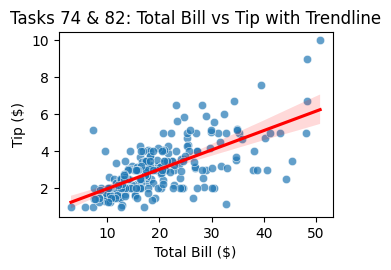

In [18]:
# 4. Scatter Plot with Regression Line
plt.subplot(2, 2, 4)
sns.scatterplot(data=df, x='total_bill', y='tip', alpha=0.7)
sns.regplot(data=df, x='total_bill', y='tip', scatter=False, color='red')
plt.title('Tasks 74 & 82: Total Bill vs Tip with Trendline')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')

plt.tight_layout()
plt.show()